## Pricing modèle marché

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad

In [37]:
T = 50  # horizon de simulation en années
N = 5000  # nombre de pas de temps
dt = T / N  # discrétisation du temps
t_grid = np.linspace(0, T, N + 1)

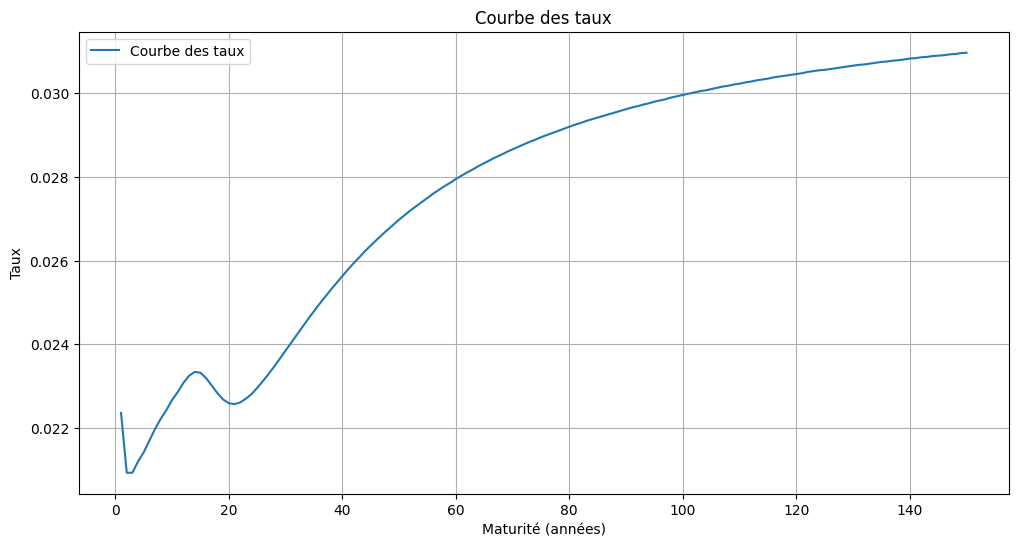

In [38]:
data = pd.ExcelFile("Input_GSE.xlsx")
courbe_taux = pd.read_excel(data, sheet_name="EIOPA Rate", usecols=[0, 1])
courbe_taux.dropna(inplace=True)

maturities = courbe_taux["Maturity"].values
zero_coupon_rates = courbe_taux["Rate"].values

# Plot the yield curve
plt.figure(figsize=(12, 6))
plt.plot(courbe_taux['Maturity'], courbe_taux['Rate'], label='Courbe des taux')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux')
plt.legend()
plt.title('Courbe des taux')
plt.grid()
plt.show()

- Interpolation courbe des taux

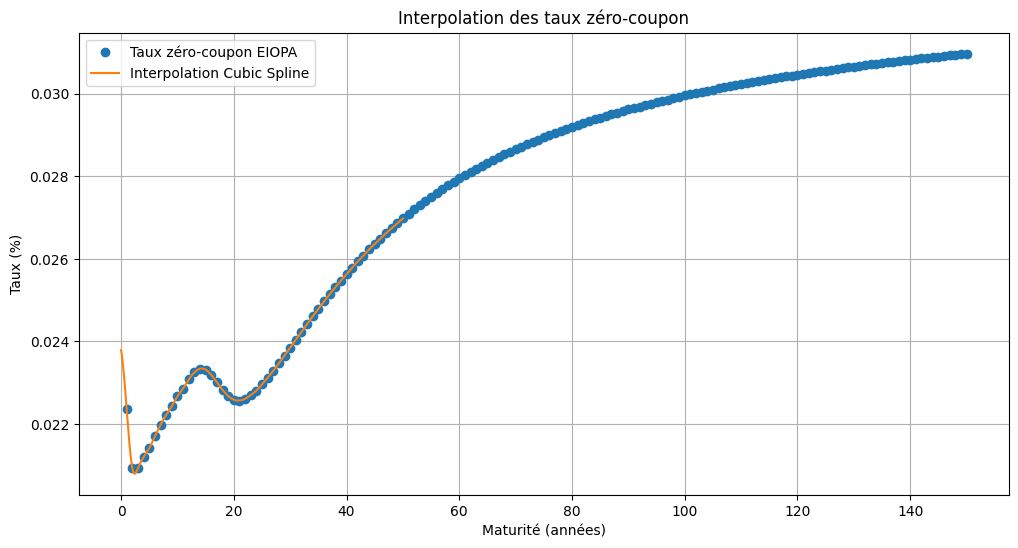

In [39]:
from scipy.interpolate import CubicSpline

# Interpolation des taux zéro-coupon
assert np.all(np.diff(maturities) > 0), "Les maturités doivent être strictement croissantes."

interpolateur_zero_coupon = CubicSpline(maturities, zero_coupon_rates, bc_type='natural')

# Calcul des taux zéro-coupon interpolés
maturities_interpol = t_grid
zero_coupon_rates_interpol = interpolateur_zero_coupon(maturities_interpol)

# Affichage des résultats
plt.figure(figsize=(12, 6))
plt.plot(maturities, zero_coupon_rates, 'o', label='Taux zéro-coupon EIOPA')
plt.plot(maturities_interpol, zero_coupon_rates_interpol, label='Interpolation Cubic Spline')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux (%)')
plt.legend()
plt.title('Interpolation des taux zéro-coupon')
plt.grid()

- Calcul des taux forward instantanés f(0,T)

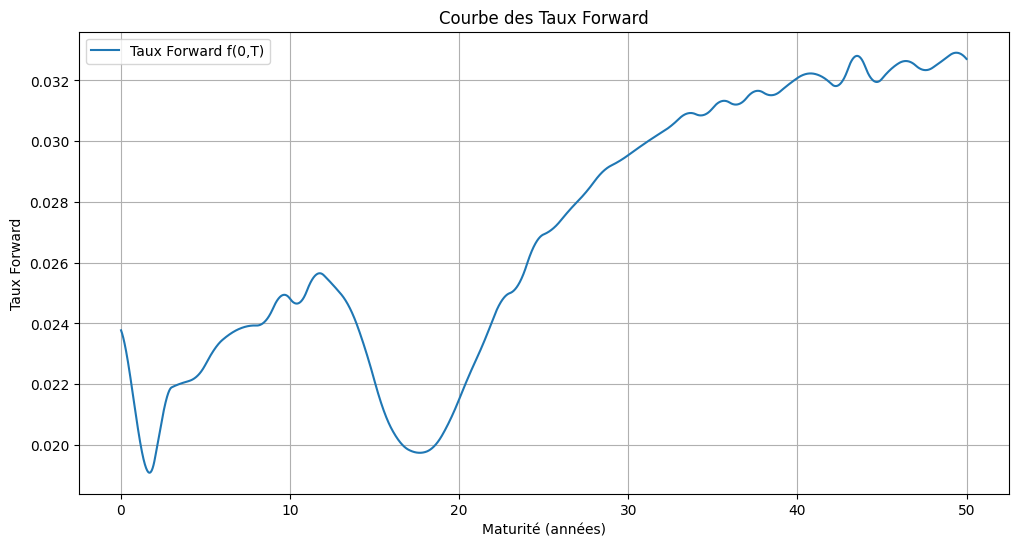

In [40]:
def calculate_forward_rates(maturities, zero_coupon_rates, dr_dt_values):
    """
    Calcule les taux forward instantanés f(0,T) pour les maturités données.

    Arguments :
    maturities : np.array : Maturités en années
    zero_coupon_rates_interpol : np.array : Taux zéro-coupon interpolés
    dr_dt_values : np.array : Dérivées des taux zéro-coupon interpolés

    Retourne :
    forward_rates : np.array : Taux forward instantanés f(0,T)
    """
    forward_rates = zero_coupon_rates + maturities * dr_dt_values
    return forward_rates

# Calcul des dérivées des taux zéro-coupon interpolés
dr_dt = interpolateur_zero_coupon.derivative()
dr_dt_values = dr_dt(t_grid[1:])
zero_coupon_rates_interpol = interpolateur_zero_coupon(t_grid[1:])

# Calcul des taux forward pour les maturités données
forward_rates = calculate_forward_rates(t_grid[1:], zero_coupon_rates_interpol, dr_dt_values)

# Affichage des résultats
df_forward_rates = pd.DataFrame({'Maturité': t_grid[1:], 'Taux Forward f(0,T)': forward_rates})


# Tracé de la courbe des taux forward
plt.figure(figsize=(12, 6))
plt.plot(df_forward_rates["Maturité"], df_forward_rates["Taux Forward f(0,T)"], label='Taux Forward f(0,T)')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux Forward')
plt.legend()
plt.title('Courbe des Taux Forward')
plt.grid()
plt.show()

- Pricing Obligation Zéro-Coupon

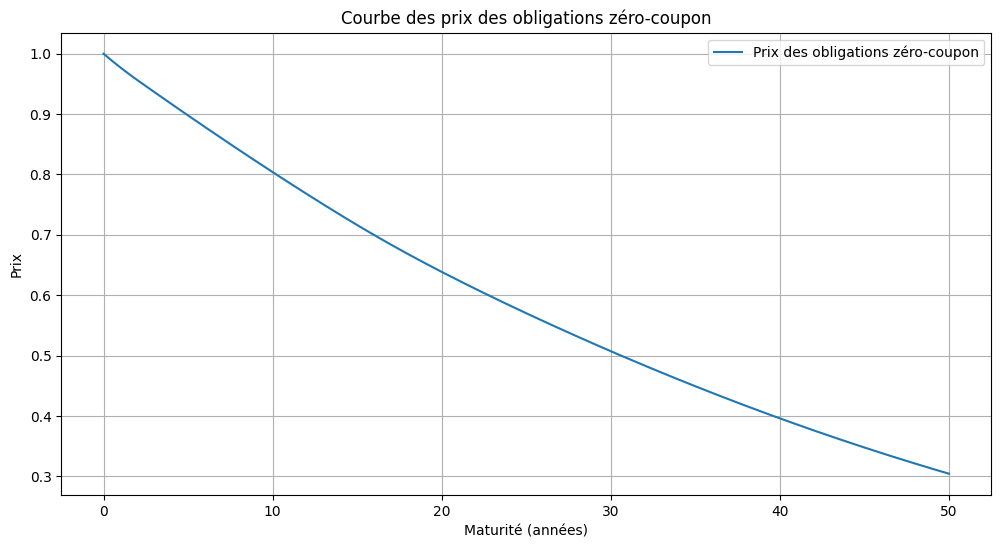

In [41]:
def zero_coupon_price_marche(maturity):
    primitive_zero_coupon = interpolateur_zero_coupon.antiderivative()

    # Calcul de l'intégrale de 0 à T
    integrale_r_T = primitive_zero_coupon(maturity) - primitive_zero_coupon(0)

    # Calcul du prix de l'obligation zéro-coupon
    P_T = np.exp(-integrale_r_T)
    
    return P_T

# Calcul des prix zéro-coupon à partir des taux observés/interpolés
prices_zero_coupon_marche = {T : zero_coupon_price_marche(T) for T in t_grid}

# Affichage des prix zéro-coupon
plt.figure(figsize=(12, 6))
plt.plot(maturities_interpol, prices_zero_coupon_marche.values(), label='Prix des obligations zéro-coupon')
plt.xlabel('Maturité (années)')
plt.ylabel('Prix')
plt.legend()
plt.title('Courbe des prix des obligations zéro-coupon')
plt.grid()
plt.show()

interpolateur_prices_zero_coupon_marche = CubicSpline(maturities_interpol, list(prices_zero_coupon_marche.values()), bc_type='natural')
derivee_prices_zero_coupon_marche = interpolateur_prices_zero_coupon_marche.derivative()

- Calcul des taux forward définis par :
$$
f(t,T) = -\frac{\partial \ln(P(t,T))}{\partial T}
$$  

C:\Users\massi\AppData\Local\Temp\ipykernel_22056\1337308777.py:2: RuntimeWarning: invalid value encountered in scalar divide
  fwr_m = (-np.log(prices_zero_coupon_marche[T])+np.log(prices_zero_coupon_marche[t]))/(T-t)


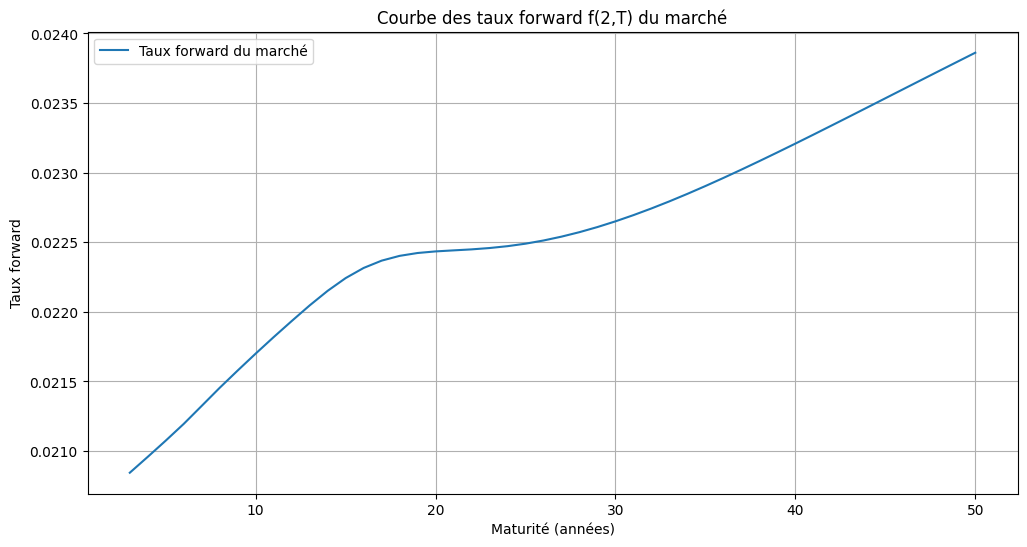

In [71]:
def forward_rate_marche(t,T):
    fwr_m = (-np.log(prices_zero_coupon_marche[T])+np.log(prices_zero_coupon_marche[t]))/(T-t)
    return fwr_m

# Calcul des taux forward du marché f(1,T)
forward_rates_marche = {T : forward_rate_marche(2, T) for T in range(2, 51)}
# Affichage des résultats
plt.figure(figsize=(12, 6))
plt.plot(forward_rates_marche.keys(), forward_rates_marche.values(), label='Taux forward du marché')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux forward')
plt.legend()
plt.title('Courbe des taux forward f(2,T) du marché')
plt.grid()
plt.show()

- Pricing Cap

In [43]:
df_implied_volatility = pd.read_excel(data, sheet_name="Cap Volatility", usecols=[0, 1])
df_implied_volatility

,Maturity,Implied Volatility
0,1,0.3412
1,2,0.3878
2,3,0.4086
3,4,0.4071
4,5,0.4031
5,6,0.3981
6,7,0.3908
7,8,0.3845
8,9,0.3774
9,10,0.3710


In [44]:
def black_cap_price(T, implied_volatility, N = 1000000, K=0.03):


    caplets_maturities = np.arange(1, T+1, 1)
    tau = np.ones_like(caplets_maturities)
    P = [prices_zero_coupon_marche[T_i] for T_i in caplets_maturities]
    F = [forward_rate_marche(t-1,t) for t in caplets_maturities]

    assert len(caplets_maturities) == len(P) == len(F) == len(tau), ("Les tailles des entrées ne correspondent pas !"
                                                                     f"Tailles : {len(caplets_maturities)}, {len(P)}, {len(F)}, {len(tau)}")    
    cap_price = 0.0

    for i in range(0, len(caplets_maturities)):
        v_i = implied_volatility
        d1 = (np.log(F[i] / K) + 0.5 * v_i**2) / v_i
        d2 = d1 - v_i
        caplet_price = 1000000 * P[i] * tau[i] * (F[i] * norm.cdf(d1) - K * norm.cdf(d2))
        cap_price += caplet_price
    return cap_price

T = 5
implied_volatility = df_implied_volatility[df_implied_volatility["Maturity"] == T]["Implied Volatility"].values  # Volatilité implicite du cap
cap_price = black_cap_price(T, implied_volatility)
print(f"Prix du cap : {cap_price}")

Prix du cap : [5631.63370047]


### Pricing Modèle théorique

In [45]:
#Posons temporairement
a, b = 0.1, 0.3  # coefficients de régression vers la moyenne
sigma, eta = 0.02, 0.01  # volatilités
rho = 0.5  # corrélation entre W1 et W2

# Et simulons x et y

dW1 = np.random.normal(0, np.sqrt(dt), N)
dW2 = rho * dW1 + np.sqrt(1 - rho**2) * np.random.normal(0, np.sqrt(dt), N)

W1 = np.concatenate(([0], np.cumsum(dW1)))
W2 = np.concatenate(([0], np.cumsum(dW2)))

# Simulation des processus x(t) et y(t)
x = np.zeros(N + 1)
y = np.zeros(N + 1)

for t in range(1, N + 1):
    x[t] = x[t-1] * np.exp(-a * dt) + sigma * np.sqrt((1 - np.exp(-2*a*dt)) / (2*a)) * np.random.normal(0, 1)
    y[t] = y[t-1] * np.exp(-b * dt) + eta * np.sqrt((1 - np.exp(-2*b*dt)) / (2*b)) * np.random.normal(0, 1)




In [46]:
# def x_et_y(a,b,sigma,eta,rho) : 

#     # Simulation des processus x(t) et y(t)
#     x = np.zeros(N + 1)
#     y = np.zeros(N + 1)

#     for t in range(1, N + 1):
#         x[t] = x[t-1] * np.exp(-a * dt) + sigma * np.sqrt((1 - np.exp(-2*a*dt)) / (2*a)) * np.random.normal(0, 1)
#         y[t] = y[t-1] * np.exp(-b * dt) + eta * np.sqrt((1 - np.exp(-2*b*dt)) / (2*b)) * np.random.normal(0, 1)

#     return [x, y]

- Pricing d'une Obligation Zéro-Coupon \( P(t, T) \)
 
Formule de $ P(t, T) $ sous G2++ :
$$
P(t,T) = A(t,T)e^{-B(t,T,a)x(t)-B(t,T,b)y(t)}
$$

où :
- $ A(t,T) $ et $ B(t,T) $ sont des fonctions explicites dépendant des paramètres du modèle.
- $ r_t $ est le **taux court** à l'instant $ t $.
---

- Expressions de $ A(t,T) $ et $ B(t,T) $

$$
B(t,T,z) = \frac{1 - e^{-z (T-t)}}{z}
$$

$$
A(t,T) = \frac{P_{M}(0,T)}{P_{M}(0,t)} \exp\left(\frac{1}{2}\left(V(t,T) - V(0,T) + V(0,t)\right)\right)
$$

avec les variances et covariances :

$
V_x(t,T) = \frac{\sigma^2}{a^2} \left[ T - t + \frac{2}{a} e^{-a(T - t)} - \frac{1}{2a} e^{-2a(T - t)} - \frac{3}{2a} \right]
$

$
V_y(t,T) = \frac{\eta^2}{b^2} \left[ T - t + \frac{2}{b} e^{-b(T - t)} - \frac{1}{2b} e^{-2b(T - t)} - \frac{3}{2b} \right]
$

$
V_xy(t,T) = \frac{2\rho\,\sigma\eta}{a b}\left(T - t - \frac{1 - e^{-a(T - t)}}{a} - \frac{1 - e^{-b(T - t)}}{b} - \frac{e^{-(a + b)(T - t)} - 1}{a + b}\right)
$  
Et finalement  
$
V_(t,T) = V_x(t,T) + V_y(t,T) + V_xy(t,T)
$

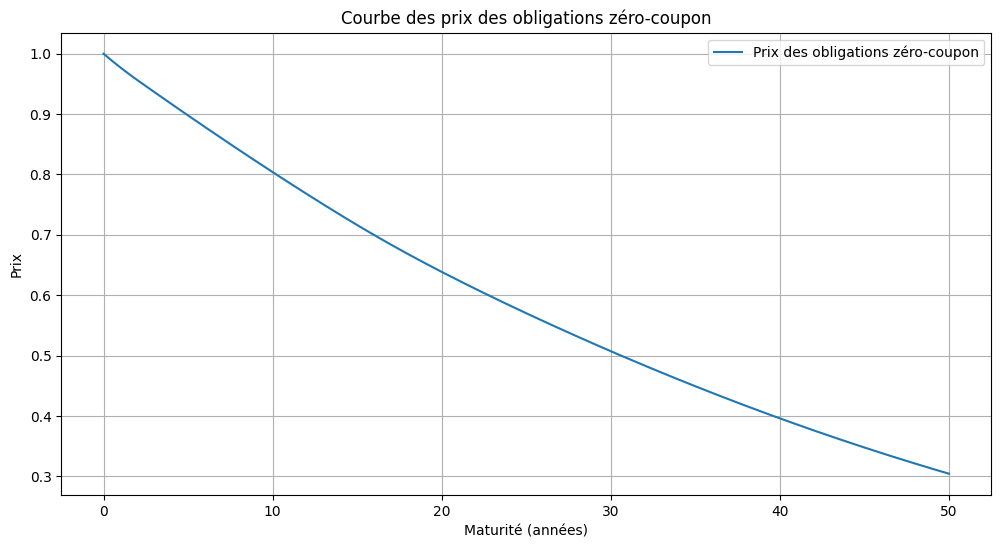

In [47]:
# Fonctions de calcul des facteurs de B(t, T, z)
def B(t, T, z):
    return (1 - np.exp(-z * (T - t))) / z


# Fonctions de calcul des variances et covariances
def var_x(t,T, a, sigma):
    return (sigma**2 / (a**2)) * ((T-t) + (2/a) * np.exp(- a * (T-t)) - (1/(2*a)) * np.exp(-2*a * (T-t)) - (3/(2*a)))

def var_y(t,T, b, eta):
    return (eta**2 / (b**2)) * ((T-t) + (2/b) * np.exp(- b * (T-t)) - (1/(2*b)) * np.exp(-2*b * (T-t)) - (3/(2*b)))

def cov_xy(t,T, a, b, sigma, eta, rho):
    return (2 * sigma * eta * rho / (a * b )) * ((T-t) - (( 1 - np.exp(- a * (T-t)) ) / a) - (( 1 - np.exp(- b * (T-t)) ) / b) - (np.exp(-(a + b) * (T-t)) - 1)/ (a + b))


def V(t,T, a, b, sigma, eta, rho):
    V_x = var_x(t,T, a, sigma)
    V_y = var_y(t,T, b, eta)
    V_xy = cov_xy(t,T, a, b, sigma, eta, rho)
    return V_x + V_y + V_xy

# Fonction de calcul des facteurs A(t, T, a, b, sigma, eta, rho)
def A(t, T, a, b, sigma, eta, rho):

    V_t_T = V(t, T, a, b, sigma, eta, rho)
    V_0_T = V(0, T, a, b, sigma, eta, rho)
    V_0_t = V(0, t, a, b, sigma, eta, rho)

    P_0_T = prices_zero_coupon_marche[T]
    P_0_t = prices_zero_coupon_marche[t]

    A_tT = (P_0_T/P_0_t)* np.exp(0.5 * (V_t_T - V_0_T + V_0_t))

    return A_tT


def prix_zero_coupon(t, T, a, b, sigma, eta, rho, x, y):
    A_tT = A(t, T, a, b, sigma, eta, rho)
    B_tT_a = B(t, T, a)
    B_tT_b = B(t, T, b)

    x_t = x[t]
    y_t = y[t]

    return A_tT * np.exp( - B_tT_a * x_t - B_tT_b  * y_t)

# Calcul des prix des obligations zéro-coupon P(0, T)
zero_coupon_prices = {T : prix_zero_coupon(0, T, a, b, sigma, eta, rho, x, y) for T in t_grid}

# Affichage des résultats
plt.figure(figsize=(12, 6))
plt.plot(maturities_interpol, zero_coupon_prices.values(), label='Prix des obligations zéro-coupon')
plt.xlabel('Maturité (années)')
plt.ylabel('Prix')
plt.legend()
plt.title('Courbe des prix des obligations zéro-coupon')
plt.grid()
plt.show()

- Calcul des taux forward f(t,T) définis par :
$$
f(t,T) = -\frac{\partial}{\partial T} \ln P(t,T) \\   
f(t,T) = -\frac{\partial}{\partial T} \ln A(t,T) + \frac{\partial B}{\partial T}(a, t, T) x(t) + \frac{\partial B}{\partial T}(b, t, T) y(t)
$$ 

In [62]:
# Dérivée partielle de Vx par rapport à T
def dvar_x_dT(t, T, a, sigma):
    return (sigma**2 / (a**2)) * (1 - 2 * np.exp( - a * (T-t)) + np.exp(-2 * a * (T-t)) )

# Dérivée partielle de Vy par rapport à T
def dvar_y_dT(t,T, b, eta):
    return (eta**2 / (b**2)) * (1 - 2 * np.exp( - b * (T-t)) + np.exp(-2 * b * (T-t)) )

# Dérivée partielle de Vxy par rapport à T
def dcov_xy_dT(t,T, a, b, sigma, eta, rho):
    return (2 * sigma * eta * rho / (a * b )) * (1 + - np.exp(- a * (T-t))) + - np.exp(- b * (T-t)) + np.exp(-(a + b) * (T-t))



# Fonction dérivée de B(t, T)
def dB_dT(T, t, z):
    return np.exp(-z * (T - t))

# Fonction dérivée de A(t, T)
def dA_dT(T, t, a, b, sigma, eta, rho):
    dVx_dT = dvar_x_dT(t,T, a, sigma)
    dVy_dT = dvar_y_dT(t,T, b, eta)
    dVxy_dT = dcov_xy_dT(t,T, a, b, sigma, eta, rho)
    dV_t_T = dVx_dT + dVy_dT + dVxy_dT

    dVx_dT_0 = dvar_x_dT(0,T, a, sigma)
    dVy_dT_0 = dvar_y_dT(0,T, b, eta)
    dVxy_dT_0= dcov_xy_dT(0,T, a, b, sigma, eta, rho)
    dV_0_T = dVx_dT_0 + dVy_dT_0 + dVxy_dT_0
    db_dT = dB_dT(T,t,a)

    P_0_T = prix_zero_coupon(0, T, a, b, sigma, eta, rho, x, y)
    P_0_t = prix_zero_coupon(0, t, a, b, sigma, eta, rho, x, y)
    
    dP_0_T = derivee_prices_zero_coupon_marche(T)
    return - forward_rate_marche(0,T) + 0.5 * (dV_t_T - dV_0_T)

# Fonction de taux forward f(t,T) sous G2++
def forward_rate_G2pp(t, T, a, b, sigma, eta, rho, x,y):
    if t == 0 :
        f_0_T = forward_rate_marche(0,T)
        return f_0_T
    dA = dA_dT(T, t, a, b, sigma, eta, rho)
    dB_a = dB_dT(T, t, a)
    dB_b = dB_dT(T, t, b)
    rate = -( dA / A(t, T, a, b, sigma, eta, rho) ) + dB_a * x[t] + dB_b * y[t]
    return max(rate,0.0000001)



# Exemple : calcul du taux forward pour T=5 ans
t = 2  # Instant présent
T = 5  # Maturité en années
f_0_T = df_forward_rates.loc[df_forward_rates["Maturité"] == T, "Taux Forward f(0,T)"].values
forward_rate_G2pp(2,3,a,b,sigma,eta,rho,x,y)

np.float64(0.0023955664441630744)

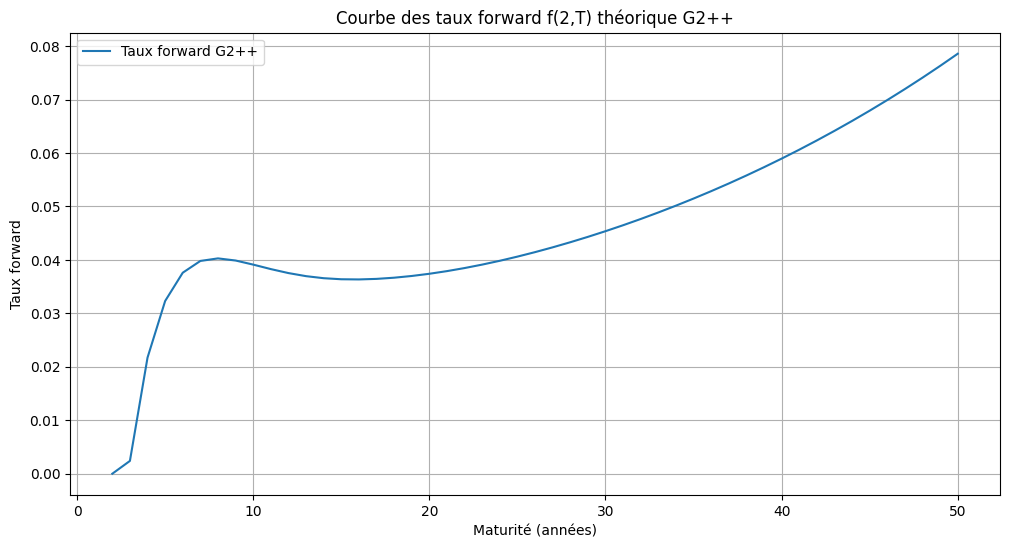

In [72]:
# Calcul des taux forward du marché f(1,T)
forward_rates_G2pp = {T : forward_rate_G2pp(2, T, a, b, sigma, eta, rho, x, y) for T in range(2, 51)}
# Affichage des résultats
plt.figure(figsize=(12, 6))
plt.plot(forward_rates_marche.keys(), forward_rates_G2pp.values(), label='Taux forward G2++')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux forward')
plt.legend()
plt.title('Courbe des taux forward f(2,T) théorique G2++')
plt.grid()
plt.show()

- Pricing Cap

In [84]:
def sigma_a_b(t, T, a, b, sigma, eta, rho):
    def integrand(s, a, b, sigma, eta, rho):
        V_x = var_x(s,T, a, sigma)
        V_y = var_y(s,T, b, eta)
        V_xy = cov_xy(s,T, a, b, sigma, eta, rho)
        return V_x + V_y + 2 * rho * V_xy

    integral_value, _ = quad(integrand, 0, T, args=(a, b, sigma, eta, rho))
    return np.sqrt(integral_value / T)


def theoric_black_cap_price(T, a, b, sigma, eta, rho, N = 1000000, K=0.03):

    caplets_maturities = np.arange(1, T+1, 1)
    tau = np.ones_like(caplets_maturities)
    sigma_a_b_ = sigma_a_b(0, T, a, b, sigma, eta, rho)
    zero_coupon_prices = {T_i : prix_zero_coupon(0, T_i, a, b, sigma, eta, rho, x, y) for T_i in caplets_maturities}
    P = [zero_coupon_prices[T_i] for T_i in caplets_maturities]
    F = [forward_rate_G2pp(t-1, t, a, b, sigma, eta, rho, x,y) for t in caplets_maturities]

    assert len(caplets_maturities) == len(P) == len(F) == len(tau), ("Les tailles des entrées ne correspondent pas !"
                                                                     f"Tailles : {len(caplets_maturities)}, {len(P)}, {len(F)}, {len(tau)}")    
    cap_price = 0.0
    caplet_prices = []
    for i in range(0, len(caplets_maturities)):
        v_i = sigma_a_b_ * np.sqrt(caplets_maturities[i])
        d1 = (np.log(F[i] / K) + 0.5 * v_i**2) / v_i
        d2 = d1 - v_i
        caplet_price = 1000000 * P[i] * tau[i] * (F[i] * norm.cdf(d1) - K * norm.cdf(d2))
        caplet_prices.append(caplet_price)
        cap_price += caplet_price

    return cap_price

T = 2
theoric_cap_price = theoric_black_cap_price(T, a, b, sigma, eta, rho)
print(f"Prix du cap : {theoric_cap_price}")

Prix du cap : 7.578512396814399e-38


- Comparaison Prix Marché et Théorique


In [85]:
# Calcul des prix des caps pour toutes les maturités dans df_implied_volatility
results = []
for maturity in df_implied_volatility["Maturity"]:
    implied_vol = df_implied_volatility[df_implied_volatility["Maturity"] == maturity]["Implied Volatility"].values[0]
    black_price = black_cap_price(maturity,implied_vol, 1000000, 0.03)
    theoric_price = theoric_black_cap_price(maturity, a, b, sigma, eta, rho)
    results.append([maturity, black_price, theoric_price])

# Création du DataFrame
df_results = pd.DataFrame(results, columns=["Maturité", "Black Cap Price", "Theoric Black Price"])
df_results

,Maturité,Black Cap Price,Theoric Black Price
0,1,1127.994345,1.176952e-274
1,2,2514.588181,7.578512e-38
2,3,3788.836997,6.617752e-12
3,4,4744.532394,6.491862e-05
4,5,5631.633700,4.136091e-02
5,6,6466.554214,6.215209e+01
6,7,7181.642855,1.424512e+03
7,8,7899.051014,5.903421e+03
8,9,8525.003224,1.568721e+04
9,10,9141.395843,3.050267e+04


- Calibrage par Nelder-Mead

In [86]:
# Algorithme de Nelder-Mead pour l'optimisation

from scipy.optimize import minimize

# Fonction d'objectif pour l'optimisation
def objective(params, maturities, zero_coupon_prices, df_forward_rates, df_implied_volatility, N, K):
    a, b, sigma, eta, rho = params
    total_error = 0.0
    
    for maturity in maturities:
        implied_vol = df_implied_volatility[df_implied_volatility["Maturity"] == maturity]["Implied Volatility"].values[0]
        black_price = black_cap_price(maturity, implied_vol)
        theoric_price = theoric_black_cap_price(maturity, a, b, sigma, eta, rho)
        total_error += (black_price - theoric_price) ** 2
    
    return total_error

# Paramètres initiaux pour l'optimisation
initial_params = [0.1, 0.3, 0.02, 0.01, 0]

# Exécution de l'optimisation
result = minimize(objective, initial_params, args=(df_implied_volatility["Maturity"], zero_coupon_prices, df_forward_rates, df_implied_volatility, N, 0.03), method='Nelder-Mead', bounds=[(1e-4, 2.0), (1e-4, 2.0), (1e-4, 1.0), (1e-4, 1.0), (-0.95, 0.95)])

# Récupération des paramètres optimisés
optimized_params = result.x
print(f"Optimized parameters: a={optimized_params[0]}, b={optimized_params[1]}, sigma={optimized_params[2]}, eta={optimized_params[3]}, rho={optimized_params[4]}")
# Calcul des prix des caps pour les paramètres optimisés
results_optimized = []
for maturity in df_implied_volatility["Maturity"]:
    implied_vol = df_implied_volatility[df_implied_volatility["Maturity"] == maturity]["Implied Volatility"].values[0]
    black_price = black_cap_price(maturity, implied_vol)
    theoric_price = theoric_black_cap_price(maturity, *optimized_params)
    results_optimized.append([maturity, black_price, theoric_price])

# Création du DataFrame pour les résultats optimisés
df_results_optimized = pd.DataFrame(results_optimized, columns=["Maturité", "Black Cap Price", "Theoric Black Price"])

# Affichage des résultats
print(df_results_optimized)
print(f"Optimization score: {result.fun}")

Optimized parameters: a=0.1986111432407587, b=1.9988687496208613, sigma=0.00010000000000000002, eta=0.03153529799559144, rho=0.9490835656077553
    Maturité  Black Cap Price  Theoric Black Price
0          1      1127.994345             0.000000
1          2      2514.588181           767.784224
2          3      3788.836997          2735.841817
3          4      4744.532394          4019.562116
4          5      5631.633700          6065.659763
5          6      6466.554214          7110.534034
6          7      7181.642855          7666.712401
7          8      7899.051014          7957.525222
8          9      8525.003224          8285.020265
9         10      9141.395843          8751.673999
10        12     10338.615571         10261.650197
11        15     12216.021474         12261.162517
12        20     16430.997543         16073.946406
13        25     22103.462441         23346.595293
14        30     29533.930795         28758.157158
Optimization score: 9292002.24124302


- Calibrage par Levenberg-Marquardt

In [87]:
from scipy.optimize import least_squares

# Fonction d'objectif pour l'optimisation
def objective(params, maturities, zero_coupon_prices, df_forward_rates, df_implied_volatility, N, K):
    a, b, sigma, eta, rho = params
    errors = []
    
    for maturity in maturities:
        implied_vol = df_implied_volatility[df_implied_volatility["Maturity"] == maturity]["Implied Volatility"].values[0]
        black_price = black_cap_price(maturity, implied_vol)
        theoric_price = theoric_black_cap_price(maturity, a, b, sigma, eta, rho)
        errors.append(black_price - theoric_price)
    
    return errors

def objective_bis(params, maturities, zero_coupon_prices, df_forward_rates, df_implied_volatility, N, K):
    a, b, sigma, eta, rho = params
    errors = []
    
    for maturity in maturities:
        implied_vol = df_implied_volatility[df_implied_volatility["Maturity"] == maturity]["Implied Volatility"].values[0]
        black_price = black_cap_price(maturity, a, b, sigma, eta, rho, implied_vol)
        theoric_price = theoric_black_cap_price(maturity, a, b, sigma, eta, rho)
        errors.append((black_price - theoric_price)/theoric_price)
    
    return errors

# Paramètres initiaux pour l'optimisation
initial_params = [0.1, 0.3, 0.02, 0.01, 0.5]

# Exécution de l'optimisation avec l'algorithme de Marquardt-Levenberg
result = least_squares(objective, initial_params, args=(df_implied_volatility["Maturity"], zero_coupon_prices, df_forward_rates, df_implied_volatility, N, 0.03), method='lm')
# result_bis = least_squares(objective_bis, initial_params, args=(df_implied_volatility["Maturity"], zero_coupon_prices, df_forward_rates, df_implied_volatility, N, 0.03), method='lm')



# Récupération des paramètres optimisés
optimized_params = result.x
print(f"Optimized parameters: a={optimized_params[0]}, b={optimized_params[1]}, sigma={optimized_params[2]}, eta={optimized_params[3]}, rho={optimized_params[4]}")

# Calcul des prix des caps pour les paramètres optimisés
results_optimized = []
for maturity in df_implied_volatility["Maturity"]:
    implied_vol = df_implied_volatility[df_implied_volatility["Maturity"] == maturity]["Implied Volatility"].values[0]
    black_price = black_cap_price(maturity, implied_vol)
    theoric_price = theoric_black_cap_price(maturity, *optimized_params)
    results_optimized.append([maturity, black_price, theoric_price])

# Création du DataFrame pour les résultats optimisés
df_results_optimized = pd.DataFrame(results_optimized, columns=["Maturité", "Black Cap Price", "Theoric Black Price"])

# Affichage des résultats
print(df_results_optimized)
print(f"Optimization score: {2 * result.cost}")

C:\Users\massi\AppData\Local\Temp\ipykernel_22056\522219997.py:9: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(integral_value / T)
C:\Users\massi\AppData\Local\Temp\ipykernel_22056\286941974.py:46: RuntimeWarning: divide by zero encountered in scalar divide
  rate = -( dA / A(t, T, a, b, sigma, eta, rho) ) + dB_a * x[t] + dB_b * y[t]


Optimized parameters: a=0.06805234501838127, b=0.49841378843018264, sigma=7.252930910516748e-05, eta=-0.0011534869392223238, rho=0.5082087284677586
    Maturité  Black Cap Price  Theoric Black Price
0          1      1127.994345         0.000000e+00
1          2      2514.588181         0.000000e+00
2          3      3788.836997         0.000000e+00
3          4      4744.532394         0.000000e+00
4          5      5631.633700        2.950363e-162
5          6      6466.554214         7.881711e-18
6          7      7181.642855         4.797069e-06
7          8      7899.051014         9.908278e-05
8          9      8525.003224         7.908495e+01
9         10      9141.395843         1.164467e+03
10        12     10338.615571         5.459942e+03
11        15     12216.021474         7.947502e+03
12        20     16430.997543         1.288396e+04
13        25     22103.462441         2.796664e+04
14        30     29533.930795         3.041599e+04
Optimization score: 456687029.299986